In [1]:
import pandas as pd
import numpy as np
import nltk
import string
from tabulate import tabulate
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\IuG_Lap1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('stopwords');
stop_words = list(stopwords.words("english"))

custom_stopwords = [
    "solution", "en", "de", "ar", "ranks", "first", "second", "third", 
    "ranked", "language", "english", "german", "arabic"
]
stop_words.extend(custom_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IuG_Lap1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def print_top_ngrams(title, ngrams):
    print(f"\n{title}")
    print(tabulate(ngrams, headers=["N-gram", "Frequency"], tablefmt="github"))

In [4]:
df = pd.read_csv("judge_pairwise_evaluation.csv")

justification_cols = [
    'Justification gemini-2.5-flash',
    'Justification qwen-plus',
    'Justification claude-3-5-haiku'
]

# Combine all justification columns into one column
df["All_Justifications"] = df[justification_cols].fillna("").agg(" ".join, axis=1)

## General analysis of all justifications

In [5]:
# Preprocess the text
def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df["Clean_Justifications"] = df["All_Justifications"].apply(preprocess)

# Create CountVectorizer for unigrams, bigrams, trigrams
def get_top_ngrams(corpus, ngram_range=(1,1), n=None):
    vec = CountVectorizer(stop_words=stop_words, ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Get top N terms
top_unigrams = get_top_ngrams(df["Clean_Justifications"], ngram_range=(1,1), n=20)
top_bigrams  = get_top_ngrams(df["Clean_Justifications"], ngram_range=(2,2), n=20)
top_trigrams = get_top_ngrams(df["Clean_Justifications"], ngram_range=(3,3), n=20)

# Print results
print_top_ngrams("Top Unigrams", top_unigrams)
print_top_ngrams("Top Bigrams", top_bigrams)
print_top_ngrams("Top Trigrams", top_trigrams)


Top Unigrams
| N-gram        |   Frequency |
|---------------|-------------|
| explanation   |        2604 |
| clear         |        2465 |
| less          |        2441 |
| mathematical  |        2299 |
| provides      |        1754 |
| making        |        1641 |
| slightly      |        1629 |
| stepbystep    |        1563 |
| correct       |        1447 |
| approach      |        1406 |
| students      |        1347 |
| learning      |        1321 |
| understanding |        1301 |
| uses          |        1188 |
| student       |        1161 |
| level         |        1160 |
| accurate      |        1158 |
| also          |        1143 |
| lacks         |        1121 |
| breakdown     |        1101 |

Top Bigrams
| N-gram                      |   Frequency |
|-----------------------------|-------------|
| slightly less               |         961 |
| stepbystep breakdown        |         804 |
| pedagogically sound         |         556 |
| comprehensive pedagogically |        

## Model specific analysis

In [6]:
from _9_justifications_analysis import analyze_justifications_per_language

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\IuG_Lap1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IuG_Lap1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### GPT justifications analysis


Top Unigrams in EN Justifications
| N-gram        |   Frequency |
|---------------|-------------|
| clear         |         166 |
| stepbystep    |         157 |
| provides      |         132 |
| best          |         122 |
| breakdown     |         117 |
| student       |         109 |
| explanation   |          96 |
| comprehensive |          80 |
| making        |          80 |
| clearly       |          76 |
| explicitly    |          73 |
| accurate      |          71 |
| strongest     |          69 |
| clearest      |          66 |
| highly        |          64 |
| also          |          62 |
| less          |          62 |
| slightly      |          61 |
| excellent     |          60 |
| learning      |          57 |

Top Bigrams
| N-gram                      |   Frequency |
|-----------------------------|-------------|
| stepbystep breakdown        |         101 |
| best provides               |          45 |
| provides clearest           |          40 |
| strongest provid

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                                                                                                            text  \
0                                       Solution 2 (en) is the strongest as it provides the most comprehensive explanation suitable for a 2nd grader, explicitly detailing the mathematical operation (+1) and linking it to the general concept of a number line, which enhances conceptual understanding and generalizability.   
1                                                                                                                                          Solution 3 (en) is the best for a 2nd grader as it clearly explains that the digit in the tens place directly tells you the number of tens, and then reinforces its value (10+10=

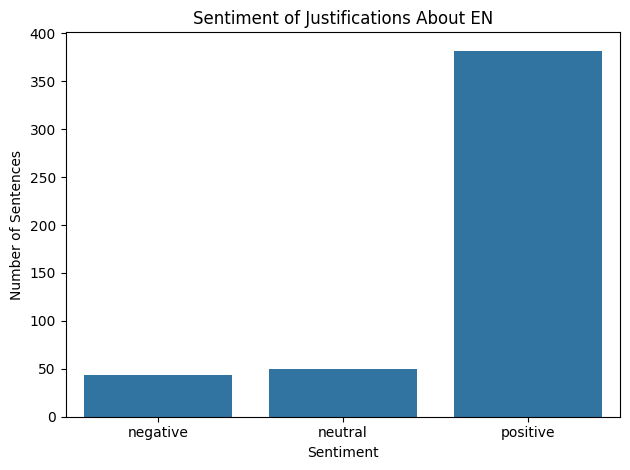


Top words per topic:
Topic 1: less, slightly, clear, also, making, accurate, detailed, offering
Topic 2: clear, accurate, strong, offering, also, stepbystep, less, slightly
Topic 3: stepbystep, breakdown, provides, clear, student, best, clearest, highly
Topic 4: clearly, comprehensive, best, explanation, provides, student, strongest, explicitly

GPT-4o-mini Conclusion:
The sentiment analysis of the justifications provided for EN math solutions indicates a predominantly positive reception, with 382 positive sentiments compared to only 44 negative ones. Key strengths highlighted include the frequent emphasis on clarity, step-by-step breakdowns, and comprehensive explanations, suggesting that many solutions are well-structured and accessible to students. However, the presence of 44 negative sentiments, alongside topics such as "less" and "slightly," points to notable weaknesses in these solutions, potentially indicating that some responses fall short in depth, engagement, or pedagogical 

In [7]:
analyze_justifications_per_language(target_language = 'en')


Top Unigrams in DE Justifications
| N-gram      |   Frequency |
|-------------|-------------|
| less        |         175 |
| clear       |         168 |
| slightly    |         129 |
| accurate    |         123 |
| also        |         109 |
| making      |          99 |
| explanation |          91 |
| stepbystep  |          91 |
| offering    |          75 |
| provides    |          71 |
| good        |          66 |
| student     |          65 |
| explicit    |          64 |
| close       |          62 |
| steps       |          61 |
| best        |          60 |
| breakdown   |          58 |
| excellent   |          54 |
| learning    |          51 |
| compared    |          50 |

Top Bigrams
| N-gram               |   Frequency |
|----------------------|-------------|
| slightly less        |          90 |
| stepbystep breakdown |          41 |
| offering clear       |          29 |
| close offering       |          25 |
| less detailed        |          24 |
| less explicit    

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                                                        text  \
0                                                                                          Solution 3 (de) is accurate and concise in presenting the ""add 1"" method but lacks the broader conceptual context and step-by-step depth found in Solution 2, placing it third.   
1                                                                               Solution 1 (de) is least suitable because it introduces division (28 ÷ 10), which is generally too advanced for introducing place value to a 2nd grader who is just learning these concepts.   
2   Solution 2 (de) is the weakest because it explicitly suggests that ""differences seem to double"" (10 then 20) based on the numbers, yet immedia

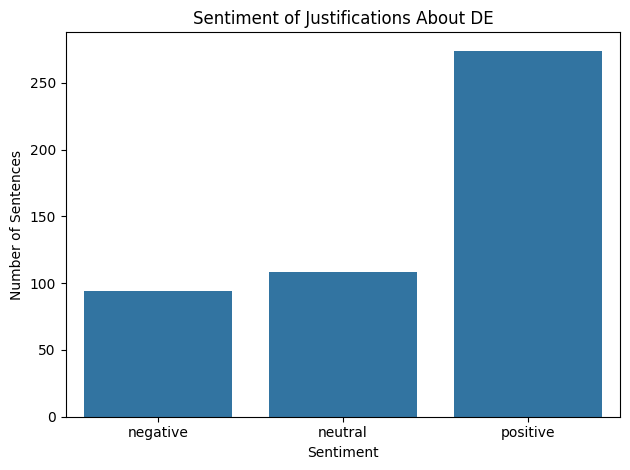


Top words per topic:
Topic 1: slightly, less, also, good, clear, accurate, calculation, step
Topic 2: clear, accurate, offering, less, slightly, also, stepbystep, explanation
Topic 3: less, making, learning, student, provides, two, accurate, breakdown
Topic 4: best, clearly, provides, student, using, method, highly, explicitly

GPT-4o-mini Conclusion:
The sentiment analysis of justifications for DE math solutions indicates a predominantly positive reception, yet a notable proportion of negative sentiments (94 out of 476 total responses) suggests that these solutions may not fully meet user expectations. The prevalence of keywords such as "less," "clear," and "accurate" in the top unigrams points to a critical concern regarding the clarity and detail of the explanations provided. Many suggestions indicate that these solutions are perceived as "slightly less" effective and "less explicit" or "less detailed," implying a gap in comprehensiveness that may hinder students' learning experien

In [8]:
analyze_justifications_per_language(target_language = 'de')


Top Unigrams in AR Justifications
| N-gram      |   Frequency |
|-------------|-------------|
| less        |         235 |
| clear       |         147 |
| making      |         124 |
| slightly    |         110 |
| accurate    |         106 |
| explanation |          88 |
| correct     |          84 |
| two         |          81 |
| learning    |          75 |
| also        |          74 |
| compared    |          69 |
| lacks       |          68 |
| stepbystep  |          68 |
| explicit    |          67 |
| steps       |          62 |
| student     |          56 |
| detailed    |          54 |
| effective   |          54 |
| provides    |          53 |
| breakdown   |          51 |

Top Bigrams
| N-gram               |   Frequency |
|----------------------|-------------|
| slightly less        |          79 |
| compared two         |          42 |
| making less          |          30 |
| less detailed        |          25 |
| stepbystep breakdown |          25 |
| less explicit    

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                                                     text  \
0                                   Solution 1 (ar) is an excellent second choice due to its directness and clarity, perfectly suited for the age group by focusing on straightforward number sequencing, making it immediately understandable for this specific problem.   
1                                                                       Solution 2 (ar) is also very good and direct, clearly identifying the tens and ones from the digits, but its brief mention of the ""decimal system"" might be slightly abstract for a 7-year-old.   
2                                                                                                                                                   Solution 

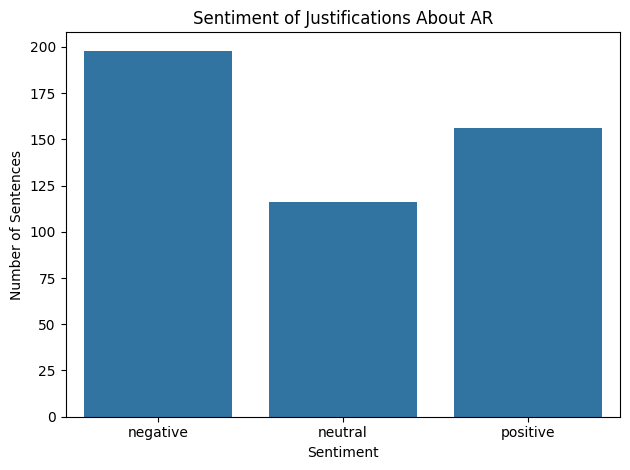


Top words per topic:
Topic 1: final, answer, calculation, understanding, student, correctly, explicitly, due
Topic 2: less, slightly, accurate, two, making, compared, correct, clear
Topic 3: fundamentally, students, problem, confusing, student, introduces, step, potentially
Topic 4: clear, offering, also, stepbystep, close, making, breakdown, excellent

GPT-4o-mini Conclusion:
The analysis of justifications for AR math solutions reveals significant weaknesses, particularly in clarity and instructional effectiveness. With a sentiment breakdown indicating more negative feedback (198) than positive (156), the comments frequently highlight that the solutions are "less detailed" and "less explicit," suggesting that users find the explanations inadequate. The dominance of phrases such as "making slightly less effective" and "slightly less detailed" points to a pervasive concern about the sufficiency of these solutions in facilitating student understanding. Furthermore, topic modeling reflec

In [9]:
analyze_justifications_per_language(target_language = 'ar')

### Gemini justifications analysis


Top Unigrams in EN Justifications
| N-gram         |   Frequency |
|----------------|-------------|
| clear          |          88 |
| less           |          73 |
| explanation    |          58 |
| also           |          56 |
| slightly       |          47 |
| accurate       |          41 |
| structured     |          41 |
| wellstructured |          35 |
| lacks          |          32 |
| making         |          32 |
| terminology    |          28 |
| comprehensive  |          26 |
| depth          |          26 |
| students       |          26 |
| learners       |          25 |
| detailed       |          24 |
| clearest       |          21 |
| strong         |          21 |
| two            |          21 |
| breakdown      |          20 |

Top Bigrams
| N-gram                 |   Frequency |
|------------------------|-------------|
| slightly less          |          38 |
| also wellstructured    |          19 |
| lacks depth            |          19 |
| less detailed      

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                            text  \
0                                                                                                                            Solution 1 (English) is the most structured and clearest for second-grade students.   
1  Solution 2 (English) is well-structured and clearly explains the concept using appropriate terminology and visual analogies (e.g., bundles of sticks), making it accessible and effective for young learners.   
2                                                                                                                                Solution 1 (English) is the clearest and most accurate for a 4th-grade student.   
3                                                                                       Solution 2 (en) is also well

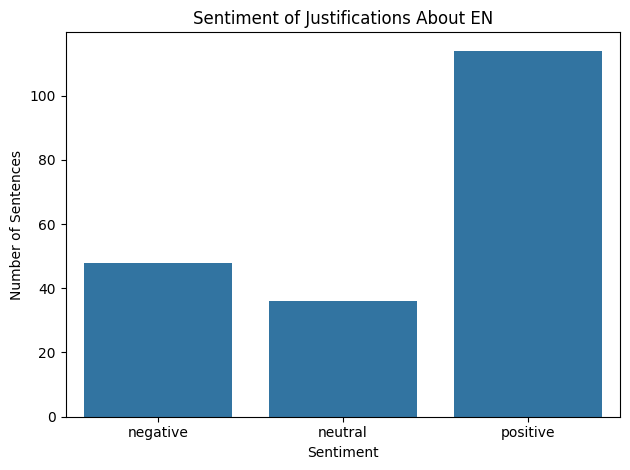


Top words per topic:
Topic 1: less, learners, lacks, making, effective, depth, concise, accurate
Topic 2: clear, also, wellstructured, slightly, less, detailed, strong, accurate
Topic 3: structured, explanation, comprehensive, clearest, precise, clear, stepbystep, clearly
Topic 4: students, clear, provides, clarity, correct, lacks, also, less

GPT-4o-mini Conclusion:
The sentiment analysis reveals a generally positive perception of the EN math solutions, with a notable number of justifications emphasizing clarity and structured explanations. However, the concurrent presence of significant negative feedback highlights critical shortcomings: specifically, many responses indicate that the solutions often "lack depth" and are "less detailed." The frequent mention of terms such as "lacks" and "less" suggests that while the solutions are appreciated for their clear structure, they fail to provide comprehensive and engaging content for learners. This duality indicates that while the foundati

In [10]:
analyze_justifications_per_language(file_dir="gemini", target_language = 'en')


Top Unigrams in DE Justifications
| N-gram         |   Frequency |
|----------------|-------------|
| clear          |          67 |
| clarity        |          47 |
| less           |          46 |
| explanation    |          41 |
| structure      |          41 |
| provides       |          38 |
| understanding  |          35 |
| stepbystep     |          34 |
| also           |          33 |
| structured     |          30 |
| breakdown      |          29 |
| students       |          29 |
| learners       |          28 |
| slightly       |          28 |
| accurate       |          25 |
| excels         |          25 |
| terminology    |          25 |
| uses           |          25 |
| making         |          24 |
| wellstructured |          24 |

Top Bigrams
| N-gram                   |   Frequency |
|--------------------------|-------------|
| clarity structure        |          24 |
| excels clarity           |          21 |
| younger learners         |          16 |
| stepbyste

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                      text  \
0                                                                                                                                                             Solution 3 (German) is correct and concise but offers the least elaboration.   
1  Solution 2 (German) is also strong, with a good balance of explanation and examples, but its informal tone (""super einfach"", ""Aktion"") may be less suitable for formal learning contexts and slightly less clear for some learners.   
2               Solution 1 (German) ranks highest because it offers a thorough and student-friendly explanation of the place value concept with clear definitions of ""Zehner"" and ""Einer,"" supported by relatable examples like money.   
3           

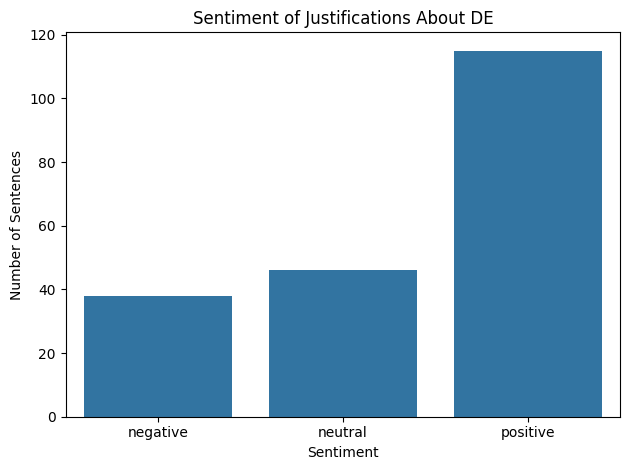


Top words per topic:
Topic 1: clarity, structure, structured, excels, approach, highest, demonstrates, pedagogical
Topic 2: slightly, learners, less, also, may, younger, uses, contains
Topic 3: clear, breakdown, detailed, less, effective, making, provides, terms
Topic 4: clear, explanation, provides, comprehensive, lacks, stepbystep, students, also

GPT-4o-mini Conclusion:
The sentiment analysis indicates a predominantly positive perception of the LLMs' justifications for DE math solutions, with significantly fewer negative comments; however, the presence of criticisms suggests notable weaknesses. The recurring themes of "clarity" and "structure" highlight strengths in pedagogical presentation, yet terms like "lacks depth," "less detailed," and "contains critical error" reveal critical shortcomings, particularly in the depth of explanation provided. Additionally, the frequent mention of "younger learners" suggests that while the solutions strive for accessibility, they may oversimplif

In [11]:
analyze_justifications_per_language(file_dir="gemini", target_language = 'de')


Top Unigrams in AR Justifications
| N-gram      |   Frequency |
|-------------|-------------|
| less        |          67 |
| clear       |          59 |
| correct     |          42 |
| lacks       |          41 |
| slightly    |          41 |
| explanation |          40 |
| accurate    |          36 |
| clarity     |          36 |
| making      |          35 |
| may         |          35 |
| also        |          34 |
| uses        |          33 |
| learners    |          31 |
| structure   |          29 |
| level       |          28 |
| steps       |          26 |
| students    |          25 |
| phrasing    |          24 |
| terminology |          24 |
| detailed    |          22 |

Top Bigrams
| N-gram                  |   Frequency |
|-------------------------|-------------|
| slightly less           |          20 |
| younger learners        |          16 |
| lacks depth             |          12 |
| lacks clarity           |          11 |
| less detailed           |          11 

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                            text  \
0  Solution 2 (Arabic) is solid and accurate, offering clear step-by-step guidance and a helpful real-life analogy with sticks, but it lacks the variety of representations found in Solution 1.   
1                                       Solution 3 (Arabic) contains accurate content but suffers slightly from verbosity and sentence structure that can be harder for young readers to follow.   
2          Solution 3 (Arabic) correctly explains the mathematical concepts and uses proper terminology, but its structure is more abstract and assumes some prior familiarity with place value.   
3                                                     Solution 3 (Arabic) is also accurate and well-structured, with a clear emphasis on understanding the positional system from ri

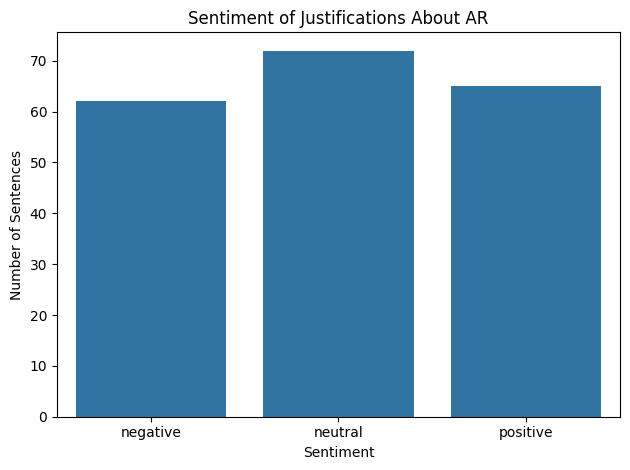


Top words per topic:
Topic 1: less, also, slightly, clear, wellstructured, detailed, accurate, making
Topic 2: lacks, clarity, structure, follows, correct, depth, less, slightly
Topic 3: clear, understanding, thorough, provides, breakdown, explanation, comprehensive, also
Topic 4: may, learners, less, uses, accurate, correct, harder, phrasing

GPT-4o-mini Conclusion:
The sentiment analysis of justifications for AR math solutions indicates a largely neutral outlook (72 neutral responses), with significant portions being positive (65) and negative (62). This mixed sentiment highlights a notable deficiency in clarity and detail, as evidenced by frequent mentions of terms like "lacks," "less," "clarity," and "depth." The high frequency of phrases such as "making slightly harder" and "younger learners follow" underlines the concern that these solutions may not adequately cater to the needs of younger or less advanced learners, leading to potential accessibility issues. Additionally, the re

In [12]:
analyze_justifications_per_language(file_dir="gemini", target_language = 'ar')

### Qwen plus justifications analysis


Top Unigrams in EN Justifications
| N-gram      |   Frequency |
|-------------|-------------|
| clear       |         206 |
| less        |         143 |
| making      |         128 |
| stepbystep  |         124 |
| explanation |         117 |
| accurate    |         107 |
| slightly    |          94 |
| breakdown   |          83 |
| offering    |          79 |
| learning    |          78 |
| highly      |          77 |
| excellent   |          75 |
| lacks       |          75 |
| provides    |          70 |
| best        |          69 |
| two         |          66 |
| explicit    |          62 |
| also        |          61 |
| close       |          60 |
| concise     |          57 |

Top Bigrams
| N-gram               |   Frequency |
|----------------------|-------------|
| stepbystep breakdown |          67 |
| slightly less        |          56 |
| close offering       |          31 |
| offering clear       |          31 |
| clear stepbystep     |          28 |
| making highly    

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                                                                                                                                                                text  \
0  Solution 3 (en) is accurate but slightly less optimal; its initial explanation of place value introduces terms like ""base-10 system"" and provides a slightly more abstract definition that might be less immediately graspable for a 7-year-old compared to the more concrete and direct approach of the other two, and it includes a somewhat redundant step in its breakdown.   
1                                                                                                                                                                  Solution 2 (en) is correct and clear but is the m

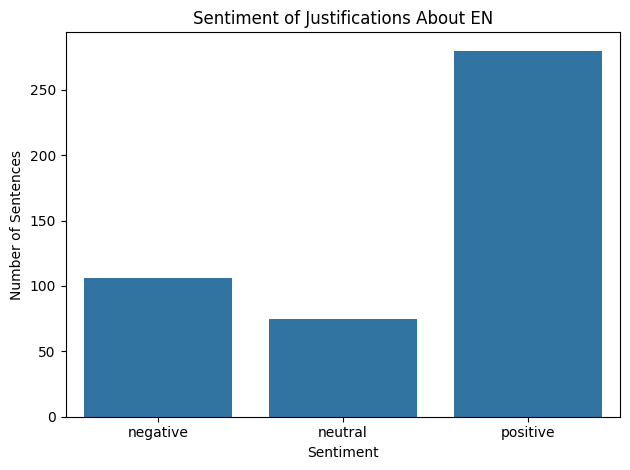


Top words per topic:
Topic 1: clear, stepbystep, explanation, offering, highly, excellent, provides, making
Topic 2: clarity, due, close, stepbystep, clear, breakdown, highly, visual
Topic 3: two, making, level, student, clear, lacks, learning, explanation
Topic 4: less, slightly, accurate, clear, making, compared, lacks, initial

GPT-4o-mini Conclusion:
The sentiment analysis reveals an overall positive perception of the English math solutions, with 280 positive sentiments compared to 106 negative ones, indicating general approval. However, the frequent use of terms like "lacks," "less," and "slightly" suggests notable deficiencies in the solutions, particularly concerning their clarity and detail. The top unigrams and bigrams point to a significant emphasis on "clear," "stepbystep," and "explanation," indicating that while many solutions strive for clarity, they often fall short of fully meeting pedagogical needs. Furthermore, the trigrams reveal concerns about the engagement level 

In [13]:
analyze_justifications_per_language(file_dir="qwen_plus", target_language = 'en')


Top Unigrams in DE Justifications
| N-gram        |   Frequency |
|---------------|-------------|
| clear         |         199 |
| less          |         152 |
| explanation   |         145 |
| stepbystep    |         112 |
| provides      |         105 |
| slightly      |          92 |
| best          |          91 |
| highly        |          85 |
| making        |          83 |
| accurate      |          82 |
| also          |          78 |
| breakdown     |          78 |
| student       |          76 |
| offering      |          73 |
| excellent     |          72 |
| learning      |          66 |
| close         |          61 |
| comprehensive |          60 |
| compared      |          57 |
| clearly       |          52 |

Top Bigrams
| N-gram                 |   Frequency |
|------------------------|-------------|
| slightly less          |          75 |
| stepbystep breakdown   |          54 |
| clear stepbystep       |          33 |
| best provides          |          28 |
| 

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                                          text  \
0                                                                                                                                       Solution 1 (de) is the strongest as it provides a clear, concise, and highly appropriate explanation for a 2nd grader.   
1             Solution 1 (de) is the most effective for a 2nd grader due to its exceptionally clear and explicit step-by-step breakdown, emphasizing the ""+10"" pattern with a highly visual progression that makes the concept intuitive for young learners.   
2                                                                                        Solution 1 (de) provides a comprehensive, clear explanation of the pattern and effectively uses simpl

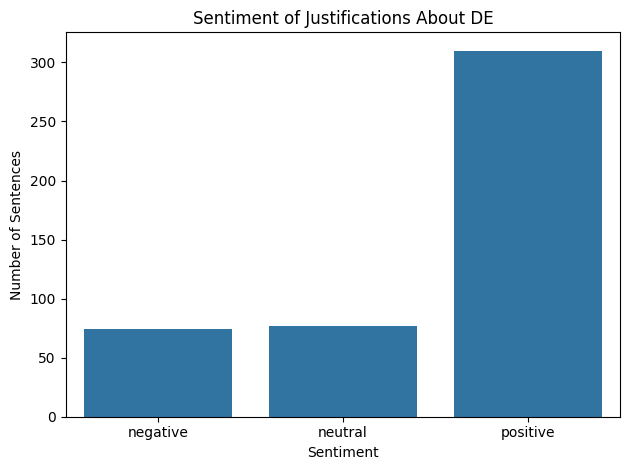


Top words per topic:
Topic 1: clear, offering, close, also, strong, excellent, explanation, stepbystep
Topic 2: best, explicitly, due, crucial, understanding, problem, stepbystep, pedagogical
Topic 3: less, slightly, compared, accurate, two, making, learning, explicit
Topic 4: clear, provides, explanation, stepbystep, best, highly, student, breakdown

GPT-4o-mini Conclusion:
The sentiment analysis indicates a predominantly positive perception of the DE math solutions, with a sentiment breakdown revealing 310 positive, 77 neutral, and 74 negative assessments. However, the presence of 74 negative sentiments suggests notable weaknesses. A recurring theme within the justifications is the critique regarding clarity and detail, as evidenced by unigrams and bigrams like "less detailed" and "less explicit," which indicate that some solutions might fail to provide the depth of explanation necessary for effective student understanding. Additionally, phrases such as “slightly less” and “less com

In [14]:
analyze_justifications_per_language(file_dir="qwen_plus", target_language = 'de')


Top Unigrams in AR Justifications
| N-gram        |   Frequency |
|---------------|-------------|
| less          |         186 |
| clear         |         185 |
| explanation   |         119 |
| also          |         105 |
| slightly      |          99 |
| making        |          92 |
| accurate      |          90 |
| two           |          83 |
| offering      |          77 |
| stepbystep    |          76 |
| provides      |          69 |
| compared      |          68 |
| student       |          62 |
| learning      |          61 |
| pedagogical   |          60 |
| excellent     |          59 |
| close         |          56 |
| comprehensive |          56 |
| strong        |          56 |
| problem       |          53 |

Top Bigrams
| N-gram                 |   Frequency |
|------------------------|-------------|
| slightly less          |          74 |
| clear stepbystep       |          28 |
| compared two           |          28 |
| stepbystep breakdown   |          25 |
| 

Device set to use cpu



Sample Sentiment-Labeled Sentences
                                                                                                                                                                                                                                 text  \
0                                                            Solution 2 (ar) is a very close second, sharing many of the same excellent qualities in its directness and clarity, making it highly effective for the target age group.   
1                          Solution 3 (ar) is a strong second, offering a mathematically robust approach by explicitly calculating the difference, which is excellent for generalizability, and its welcoming framework for learning.   
2  Solution 3 (ar) is clear but could pose minor language comprehension challenges for 2nd graders, and it does not incorporate the technical terms in a way that reinforces understanding as effectively as the first two solutions.   
3                               

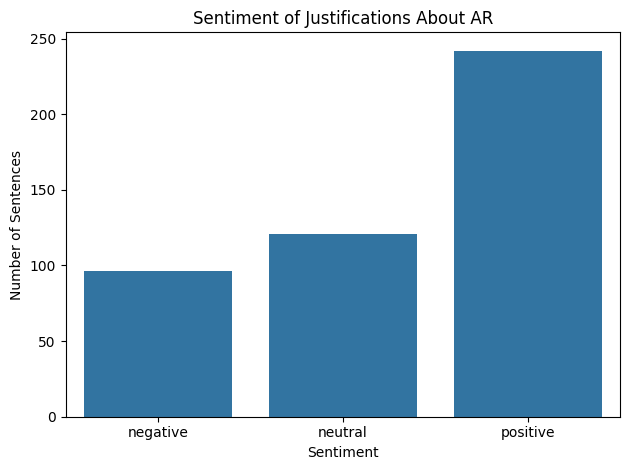


Top words per topic:
Topic 1: clear, less, explanation, also, understanding, two, slightly, lacks
Topic 2: clear, using, student, provides, problem, stepbystep, offering, like
Topic 3: less, slightly, accurate, compared, two, making, learning, wellstructured
Topic 4: clear, offering, explanation, excellent, close, strong, highly, also

GPT-4o-mini Conclusion:
The sentiment analysis indicates a predominantly positive reception of the AR math solutions, with 242 positive sentiments compared to 96 negative ones. However, several weaknesses emerge from the justifications provided. The frequent mention of terms like "less," "clear," and "explanation" suggests that while these solutions may be strong in clarity and structure, they often fall short of being comprehensive, with indications of being "less detailed" or "slightly less precise." This implies that while the solutions may facilitate understanding through step-by-step breakdowns, they may inadequately address complex concepts or omi

In [15]:
analyze_justifications_per_language(file_dir="qwen_plus", target_language = 'ar')